# Detección Inteligente de Arritmias con ECG
**Autor:** Eduardo González Gutiérrez

## Librerías

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, accuracy_score, roc_curve, auc)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

## Carga del Dataset y Preparación de Etiquetas

In [25]:
ruta_train = 'mitbih_train.csv'
ruta_test  = 'mitbih_test.csv'

df_train = pd.read_csv(ruta_train, header=None)
df_test  = pd.read_csv(ruta_test,  header=None)

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')

Train: (87554, 188)  |  Test: (21892, 188)


In [26]:
# Las primeras 187 columnas son la señal ECG; la columna 188 es la clase
X_train = df_train.iloc[:, :187].values
X_test  = df_test.iloc[:,  :187].values

# Etiqueta multiclase (5 clases: 0, 1, 2, 3, 4)
y_train_5 = df_train.iloc[:, 187].values.astype(int)
y_test_5  = df_test.iloc[:,  187].values.astype(int)

# Etiqueta binaria: 0 = normal, 1 = anómalo (clases 1-4)
y_train_bin = (y_train_5 != 0).astype(int)
y_test_bin  = (y_test_5  != 0).astype(int)

# Mapeo de nombres de clases
CLASS_NAMES = {
    0: 'Normal (N)',
    1: 'Supraventricular (S)',
    2: 'Ventricular (V)',
    3: 'Fusión (F)',
    4: 'Ruido (Q)'
}

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Clases únicas en train: {np.unique(y_train_5)}')
print(f'Distribución binaria train: Normal={np.sum(y_train_bin==0):,} | Anómalo={np.sum(y_train_bin==1):,}')

X_train: (87554, 187) | X_test: (21892, 187)
Clases únicas en train: [0 1 2 3 4]
Distribución binaria train: Normal=72,471 | Anómalo=15,083


## Exploración Inicial y Análisis Descriptivo (EDA)

### Distribución de clases

               Clase  Conteo  Porcentaje (%)
          Normal (N)   72471           82.77
Supraventricular (S)    2223            2.54
     Ventricular (V)    5788            6.61
          Fusión (F)     641            0.73
           Ruido (Q)    6431            7.35


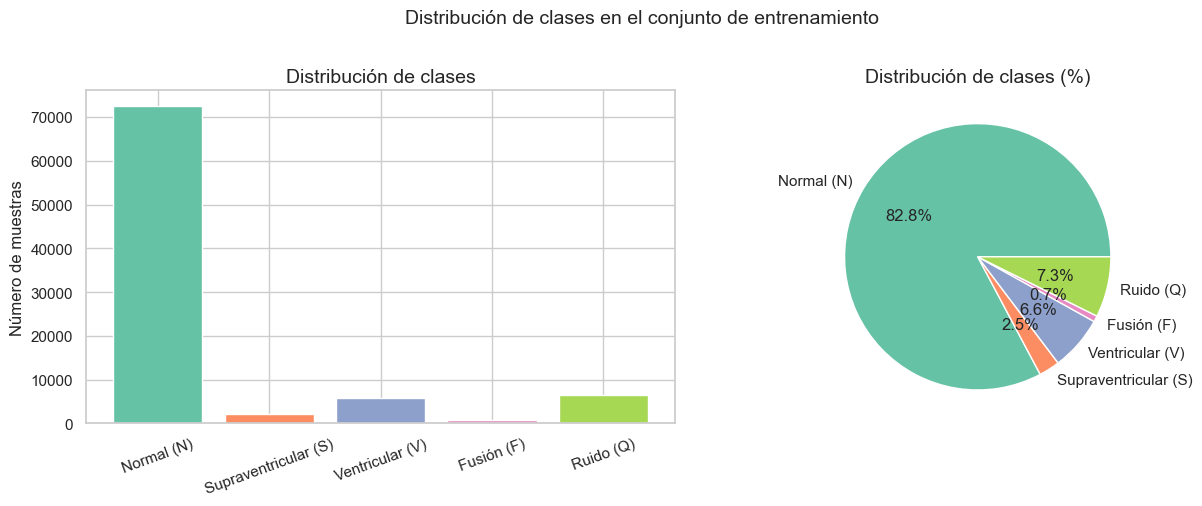

In [27]:
# Número de clases y su porcentaje sobre el total
numero_clases = pd.Series(y_train_5).value_counts().sort_index()
porcentaje_clases = (numero_clases / len(y_train_5) * 100).round(2)

# Tabla de distribución de clases con conteo y porcentaje
df_distribuciones = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in numero_clases.index],
    'Conteo': numero_clases.values,
    'Porcentaje (%)': porcentaje_clases.values
})
print(df_distribuciones.to_string(index=False))

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar([CLASS_NAMES[i] for i in numero_clases.index], numero_clases.values, color=sns.color_palette('Set2', 5))
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Número de muestras')
axes[0].tick_params(axis='x', rotation=20)

# Gráfico de sector (pie chart)
axes[1].pie(numero_clases.values, labels=[CLASS_NAMES[i] for i in numero_clases.index], autopct='%1.1f%%', colors=sns.color_palette('Set2', 5))
axes[1].set_title('Distribución de clases (%)')

plt.suptitle('Distribución de clases en el conjunto de entrenamiento', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Estadística Descriptiva

Estadísticas de las 187 variables predictoras:
           mean       std    min       25%       50%       75%    max
count  187.0000  187.0000  187.0  187.0000  187.0000  187.0000  187.0
mean     0.1743    0.1754    0.0    0.0599    0.1241    0.2294    1.0
std      0.1309    0.0586    0.0    0.0984    0.1382    0.1879    0.0
min      0.0028    0.0319    0.0    0.0000    0.0000    0.0000    1.0
25%      0.0474    0.1499    0.0    0.0000    0.0000    0.0000    1.0
50%      0.2018    0.1926    0.0    0.0000    0.1295    0.3055    1.0
75%      0.2716    0.2209    0.0    0.1099    0.2344    0.3698    1.0
max      0.8904    0.2519    0.0    0.9219    0.9913    1.0000    1.0


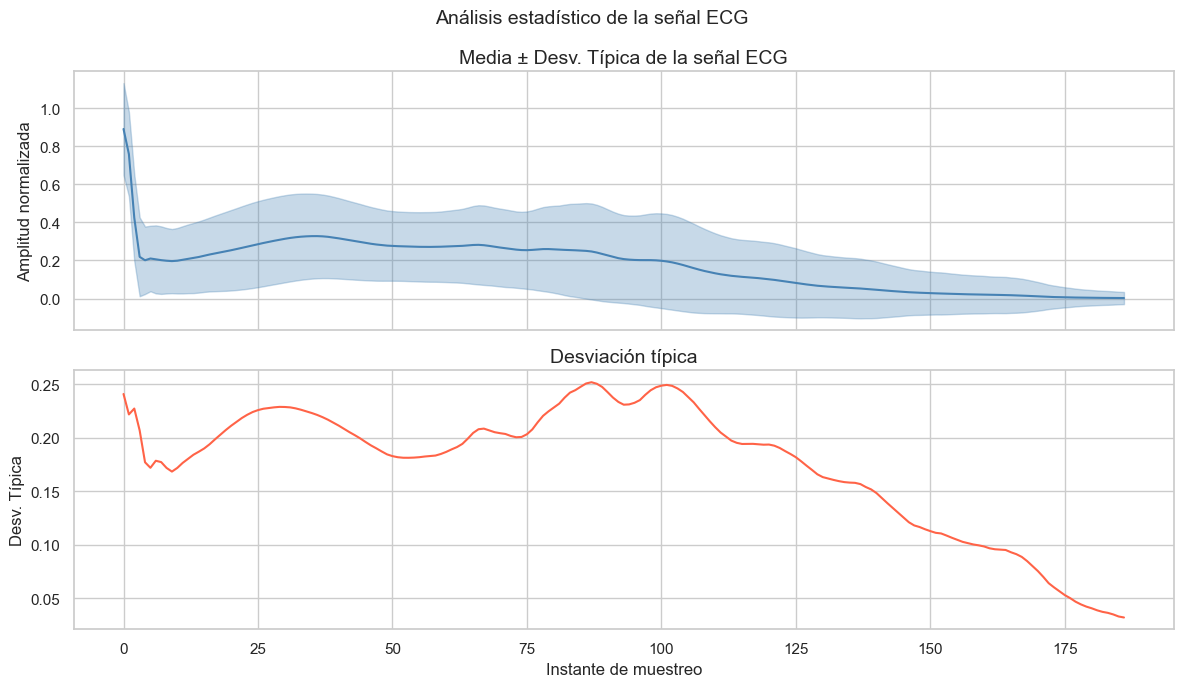

In [28]:
# Creamos un DataFrame con estadísticas descriptivas por columna 
df_X = pd.DataFrame(X_train)
estadisticas = df_X.describe().T  # media, std, min, percentiles, max por columna

# Mostramos un resumen por filas
print('Estadísticas de las 187 variables predictoras:')
print(estadisticas[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].describe().round(4))

# Visualizamos media y desviación típica a lo largo de la señal
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(estadisticas['mean'].values, color='steelblue', linewidth=1.5)
axes[0].fill_between(range(187), estadisticas['mean'] - estadisticas['std'], estadisticas['mean'] + estadisticas['std'], alpha=0.3, color='steelblue')
axes[0].set_title('Media ± Desv. Típica de la señal ECG')
axes[0].set_ylabel('Amplitud normalizada')

axes[1].plot(estadisticas['std'].values, color='tomato', linewidth=1.5)
axes[1].set_title('Desviación típica')
axes[1].set_ylabel('Desv. Típica')
axes[1].set_xlabel('Instante de muestreo')

plt.suptitle('Análisis estadístico de la señal ECG', fontsize=14)
plt.tight_layout()
plt.show()

Estadísticas por clase
        media             std          maximo        varianza        
         mean  median    mean  median    mean median     mean  median
clase                                                                
0      0.1619  0.1318  0.1861  0.1770  1.0000    1.0   0.0369  0.0313
1      0.1948  0.1925  0.1868  0.1919  0.9919    1.0   0.0382  0.0368
2      0.2438  0.2156  0.2290  0.2117  0.9995    1.0   0.0568  0.0448
3      0.1073  0.0997  0.1813  0.1786  1.0000    1.0   0.0339  0.0319
4      0.2509  0.2580  0.2412  0.2440  1.0000    1.0   0.0618  0.0596


C:\Users\Delante\AppData\Local\Temp\ipykernel_19896\313323877.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_latidos, x='clase', y='maximo', palette='Set2', ax=axes[0])
C:\Users\Delante\AppData\Local\Temp\ipykernel_19896\313323877.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([CLASS_NAMES[i] for i in range(5)], rotation=20)
C:\Users\Delante\AppData\Local\Temp\ipykernel_19896\313323877.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_latidos, x='clase', y='std', palette='Set2', ax=axes[1])
C:\Users\Delante\AppData\Local\Temp\ipykernel_19896\313323877.p

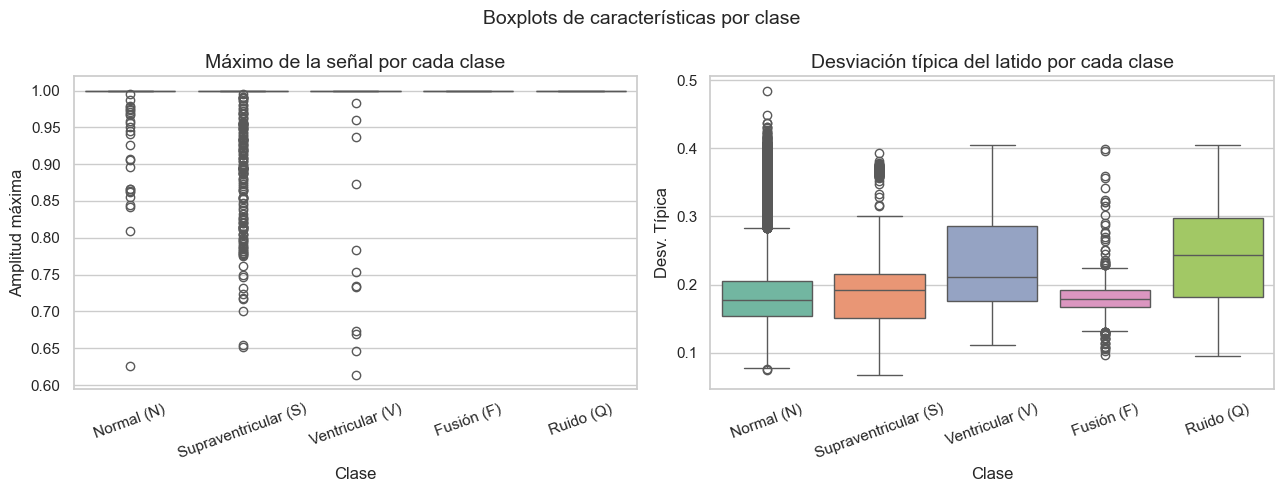

In [29]:
# Calculamos media, std, máximo y varianza de cada latido y agrupamos por clase   
df_latidos = pd.DataFrame({
    'media':    X_train.mean(axis=1),
    'std':      X_train.std(axis=1),
    'maximo':   X_train.max(axis=1),
    'varianza': X_train.var(axis=1),
    'clase':    y_train_5
})

print('Estadísticas por clase')
print(df_latidos.groupby('clase')[['media', 'std', 'maximo', 'varianza']].agg(['mean', 'median']).round(4))

# Boxplots del máximo del latido por cada clase
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_latidos, x='clase', y='maximo', palette='Set2', ax=axes[0])
axes[0].set_title('Máximo de la señal por cada clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Amplitud máxima')
axes[0].set_xticklabels([CLASS_NAMES[i] for i in range(5)], rotation=20)

sns.boxplot(data=df_latidos, x='clase', y='std', palette='Set2', ax=axes[1])
axes[1].set_title('Desviación típica del latido por cada clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Desv. Típica')
axes[1].set_xticklabels([CLASS_NAMES[i] for i in range(5)], rotation=20)

plt.suptitle('Boxplots de características por clase', fontsize=14)
plt.tight_layout()
plt.show()

### Señales típicas por clase

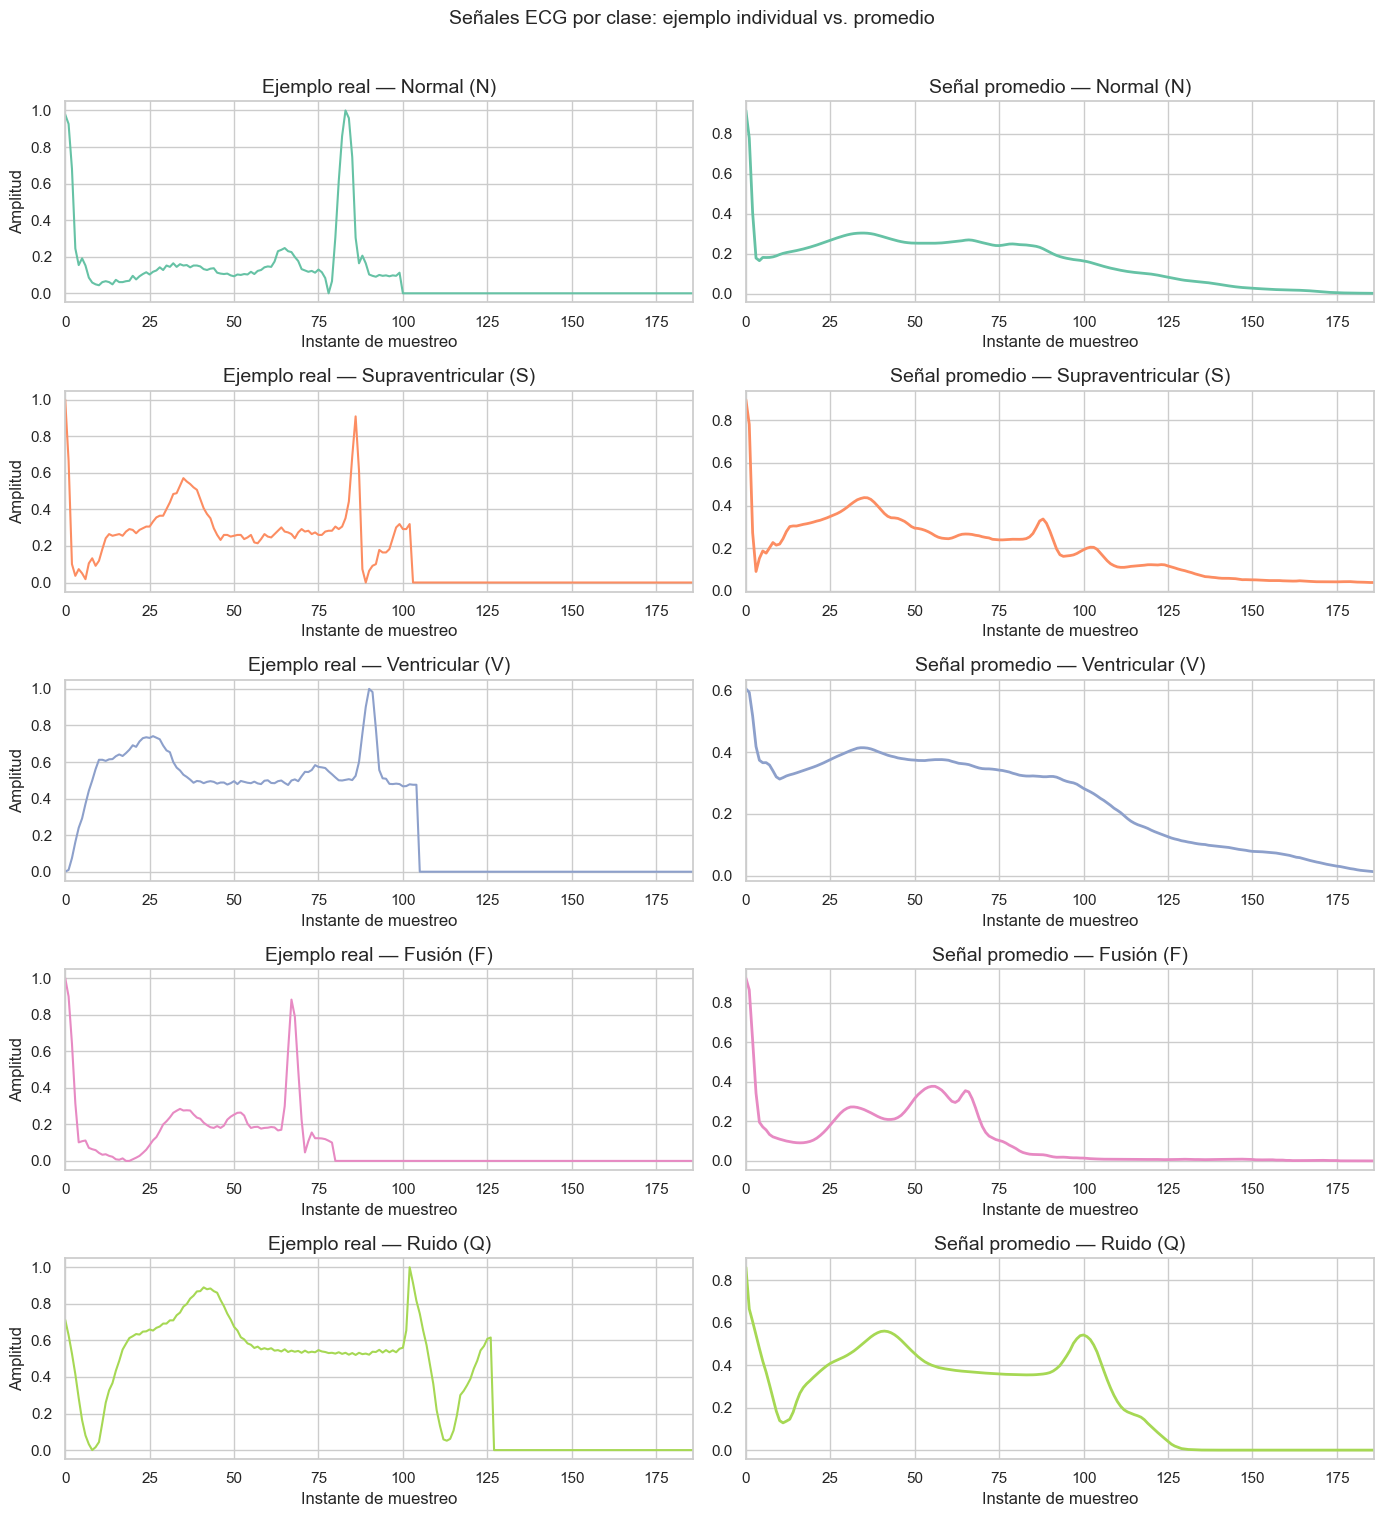

In [30]:
# Mostramos un ejemplo real de la clase y la señal promedio para cada clase
fig, axes = plt.subplots(5, 2, figsize=(14, 15))
colors = sns.color_palette('Set2', 5)

for clase in range(5):
    idx_clase = np.where(y_train_5 == clase)[0]
    
    # Señal ejemplo de ejemplo (la primera de la clase)
    ejemplo = X_train[idx_clase[0]]
    axes[clase, 0].plot(ejemplo, color=colors[clase], linewidth=1.5)
    axes[clase, 0].set_title(f'Ejemplo real — {CLASS_NAMES[clase]}')
    axes[clase, 0].set_ylabel('Amplitud')
    
    # Señal promedio de la clase
    media_clase = X_train[idx_clase].mean(axis=0)
    axes[clase, 1].plot(media_clase, color=colors[clase], linewidth=2)
    axes[clase, 1].set_title(f'Señal promedio — {CLASS_NAMES[clase]}')
    
    for ax in axes[clase]:
        ax.set_xlabel('Instante de muestreo')
        ax.set_xlim(0, 186)

plt.suptitle('Señales ECG por clase: ejemplo individual vs. promedio', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.4 Histogramas por clase (variable seleccionada)

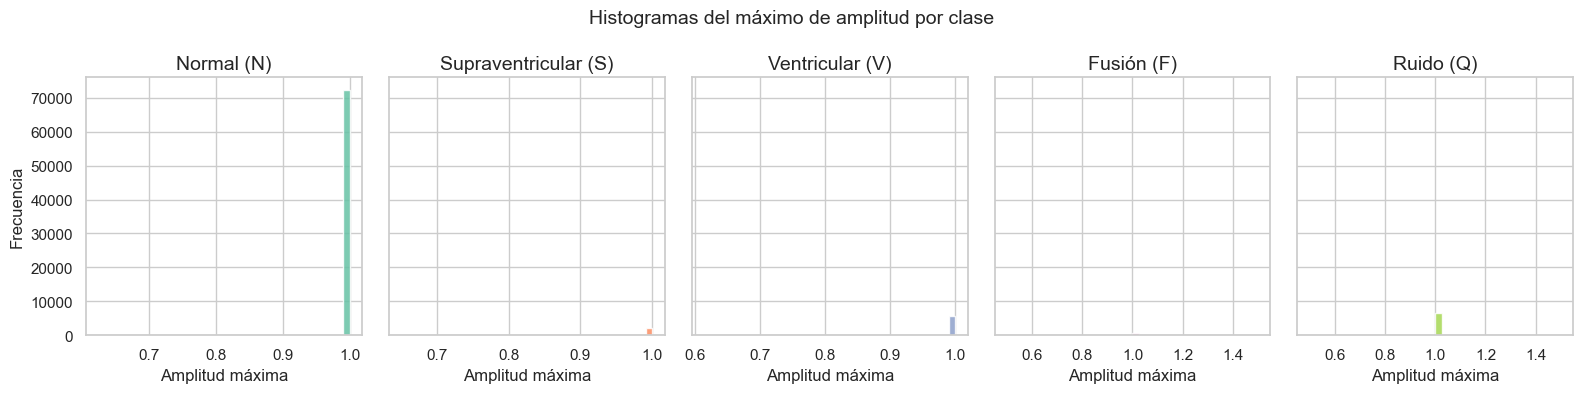

In [31]:
# Histograma del máximo de amplitud por clase
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
colors = sns.color_palette('Set2', 5)

for clase in range(5):
    valores = df_latidos.loc[df_latidos['clase'] == clase, 'maximo']
    axes[clase].hist(valores, bins=40, color=colors[clase], edgecolor='white', alpha=0.85)
    axes[clase].set_title(f'{CLASS_NAMES[clase]}')
    axes[clase].set_xlabel('Amplitud máxima')
    if clase == 0:
        axes[clase].set_ylabel('Frecuencia')

plt.suptitle('Histogramas del máximo de amplitud por clase', fontsize=14)
plt.tight_layout()
plt.show()

## Reducción de Dimensionalidad (PCA)

In [32]:
# Estándarización (obligatoria antes de PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

PC1 varianza explicada: 36.63%
PC2 varianza explicada: 15.63%
PC1+PC2 acumulada:      52.26%
Componentes para 90% varianza: 26


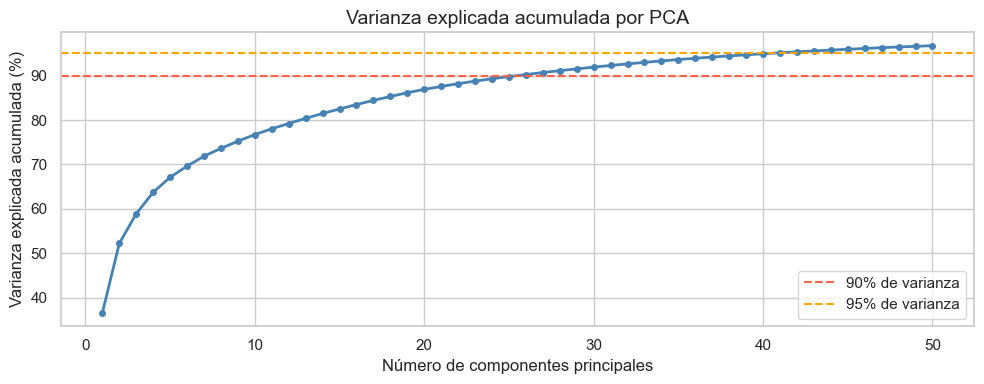

In [33]:
# calculamos PCA con 50 componentes para analizar la varianza explicada
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_train_scaled)

varianza_explicada  = pca.explained_variance_ratio_
varianza_acumulada  = np.cumsum(varianza_explicada)

print(f'PC1 varianza explicada: {varianza_explicada[0]*100:.2f}%')
print(f'PC2 varianza explicada: {varianza_explicada[1]*100:.2f}%')
print(f'PC1+PC2 acumulada:      {varianza_acumulada[1]*100:.2f}%')
print(f'Componentes para 90% varianza: {np.argmax(varianza_acumulada >= 0.90) + 1}')

# Curva de varianza explicada acumulada
plt.figure(figsize=(10, 4))
plt.plot(range(1, 51), varianza_acumulada * 100, marker='o', markersize=4, linewidth=2, color='steelblue')
plt.axhline(y=90, color='tomato', linestyle='--', label='90% de varianza')
plt.axhline(y=95, color='orange', linestyle='--', label='95% de varianza')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada (%)')
plt.title('Varianza explicada acumulada por PCA')
plt.legend()
plt.tight_layout()
plt.show()

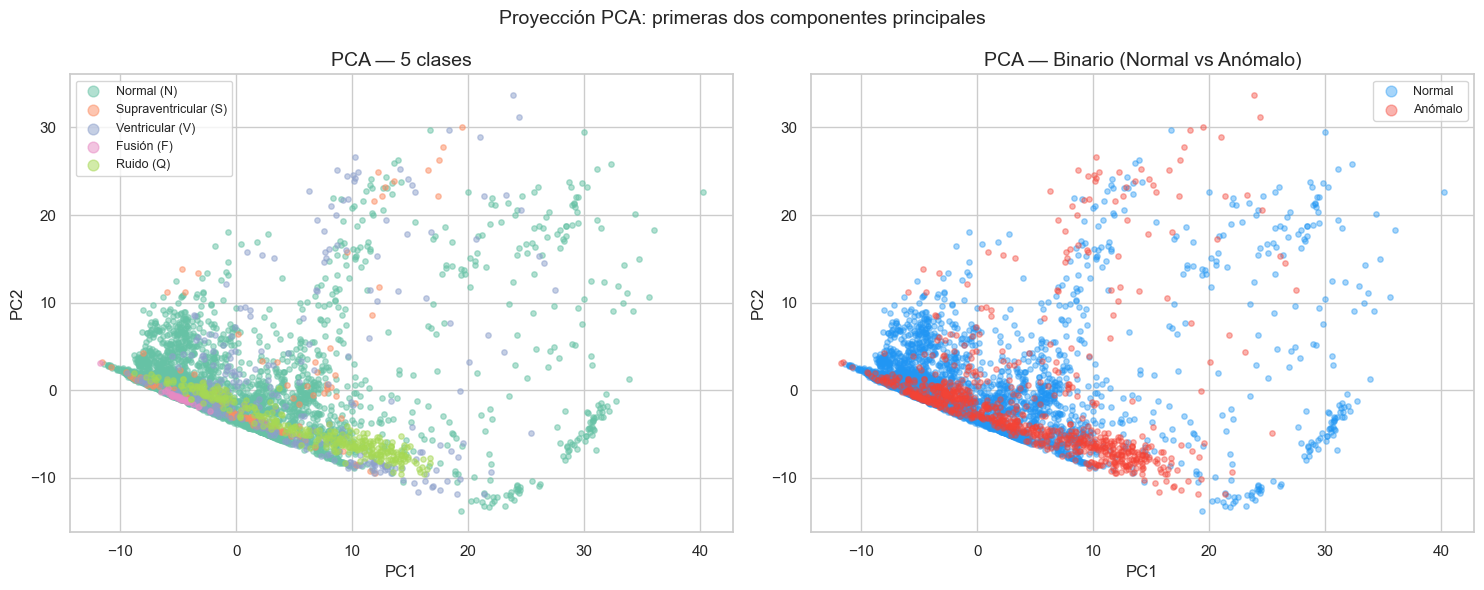

In [34]:
# Scatter plot con 5000 ejemplos aleatorios para no saturar el gráfico
np.random.seed(42)
numero_ejemplos = 5000
array_ejemplos = np.random.choice(len(X_pca), size=numero_ejemplos, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = sns.color_palette('Set2', 5)

# Gráfico 5 clases
for clase in range(5):
    mask = y_train_5[array_ejemplos] == clase
    axes[0].scatter(X_pca[array_ejemplos][mask, 0], X_pca[array_ejemplos][mask, 1], label=CLASS_NAMES[clase], alpha=0.5, s=15, color=colors[clase])
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA — 5 clases')
axes[0].legend(markerscale=2, fontsize=9)

# Gráfico binario
bin_colors = ['#2196F3', '#F44336']
bin_labels = ['Normal', 'Anómalo']
y_bin_sample = y_train_bin[array_ejemplos]
for b in range(2):
    mask = y_bin_sample == b
    axes[1].scatter(X_pca[array_ejemplos][mask, 0], X_pca[array_ejemplos][mask, 1], label=bin_labels[b], alpha=0.4, s=15, color=bin_colors[b])
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA — Binario (Normal vs Anómalo)')
axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle('Proyección PCA: primeras dos componentes principales', fontsize=14)
plt.tight_layout()
plt.show()

## Modelos de Clasificación (Binario)

In [35]:
# Para Regresión Logística y Naive Bayes usamos los datos escalados; para árbol los originales
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}')
print(f'Normal train: {np.sum(y_train_bin==0):,}  |  Anómalo train: {np.sum(y_train_bin==1):,}')

Train: (87554, 187)  |  Test: (21892, 187)
Normal train: 72,471  |  Anómalo train: 15,083


In [36]:
# MODELO 1: Regresión Logística
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train_bin)
y_pred_lr = lr.predict(X_test_scaled)

In [37]:
# MODELO 2: Árbol de Decisión
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train_bin)  # el árbol no requiere escalado
y_pred_dt = dt.predict(X_test)

In [38]:
# MODELO 3: Naive Bayes (Gaussiano)
nb = GaussianNB()
nb.fit(X_train_scaled, y_train_bin)
y_pred_nb = nb.predict(X_test_scaled)

In [39]:
# Evaluamos los modelos con las métricas principales
def evaluar_modelo(nombre, y_true, y_pred):
    return {
        'Modelo': nombre,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4)
    }

resultados = [
    evaluar_modelo('Regresión Logística', y_test_bin, y_pred_lr),
    evaluar_modelo('Árbol de Decisión',   y_test_bin, y_pred_dt),
    evaluar_modelo('Naive Bayes',          y_test_bin, y_pred_nb),
]

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('Comparativa de modelos sobre el conjunto de prueba')
print(df_resultados.to_string())

Comparativa de modelos sobre el conjunto de prueba
                     Accuracy  Precision  Recall  F1-Score
Modelo                                                    
Regresión Logística    0.8419     0.5285  0.7700    0.6268
Árbol de Decisión      0.9447     0.8167  0.8760    0.8453
Naive Bayes            0.8101     0.4531  0.4918    0.4717


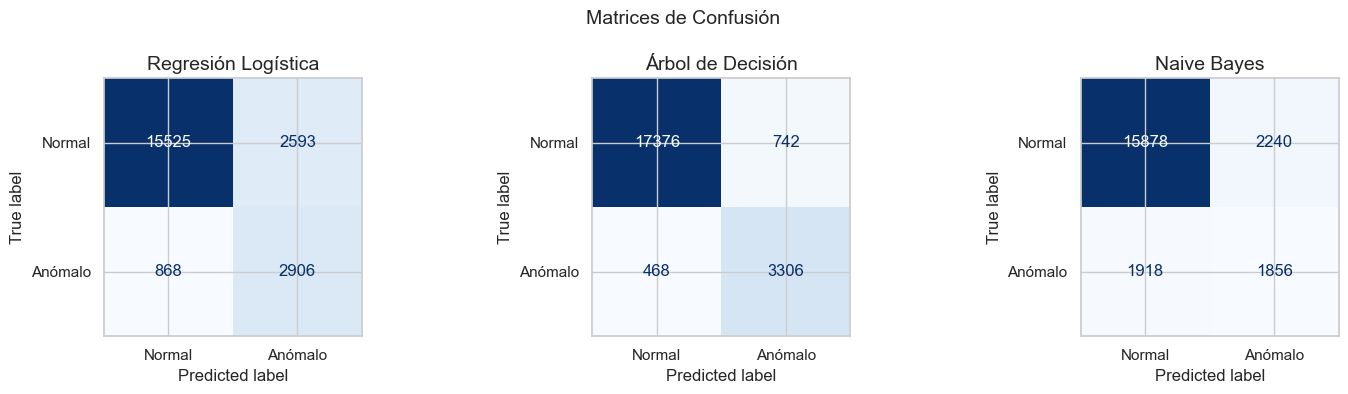

In [40]:
# Matriz de confusión para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modelos = [
    ('Regresión Logística', y_pred_lr),
    ('Árbol de Decisión',   y_pred_dt),
    ('Naive Bayes',          y_pred_nb),
]

for ax, (nombre, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_test_bin, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anómalo'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)

plt.suptitle('Matrices de Confusión', fontsize=14)
plt.tight_layout()
plt.show()

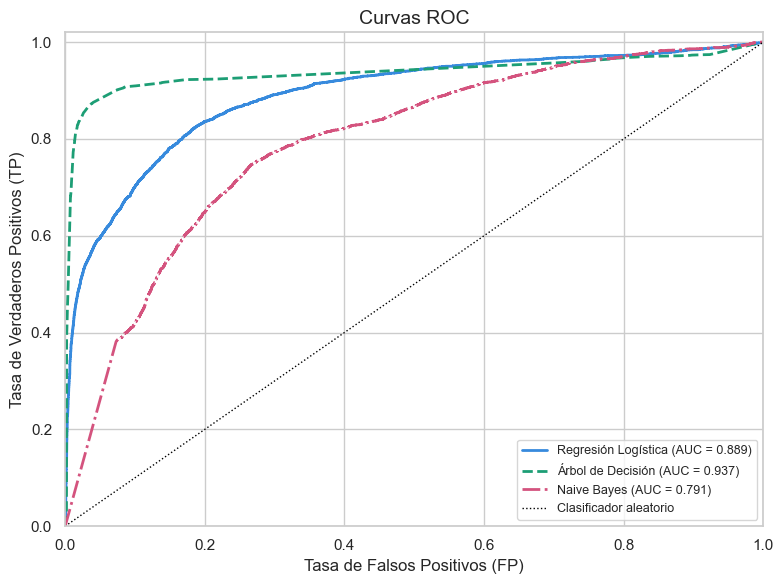

In [42]:
# Probabilidades para AUC
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dt.predict_proba(X_test)[:, 1]
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

# Curvas ROC y AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test_bin, y_prob_dt)
fpr_nb, tpr_nb, _ = roc_curve(y_test_bin, y_prob_nb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_nb = auc(fpr_nb, tpr_nb)

# Graficamos las curvas ROC de los tres modelos
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, color='#378ADD', linewidth=2, label=f'Regresión Logística (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, color='#1D9E75', linewidth=2, linestyle='--', label=f'Árbol de Decisión (AUC = {auc_dt:.3f})')
plt.plot(fpr_nb, tpr_nb, color='#D4537E', linewidth=2, linestyle='-.', label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FP)')
plt.ylabel('Tasa de Verdaderos Positivos (TP)')
plt.title('Curvas ROC')
plt.legend(fontsize=9)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.tight_layout()
plt.show()

## Probabilidades Condicionales y Teorema de Bayes

In [50]:
# Filtramos solo las clases 0 y 2
clases_0_2 = np.isin(y_train_5, [0, 2])
X_bayes  = X_train[clases_0_2]
y_bayes  = y_train_5[clases_0_2]

n_total = len(y_bayes)
n_0 = np.sum(y_bayes == 0)
n_2 = np.sum(y_bayes == 2)

print(f'Muestras clase 0 (Normal): {n_0:,}')
print(f'Muestras clase 2 (Ventricular): {n_2:,}')
print(f'Total subconjunto: {n_total:,}')

Muestras clase 0 (Normal): 72,471
Muestras clase 2 (Ventricular): 5,788
Total subconjunto: 78,259


In [54]:
# Definimos el evento X: "el máximo del latido supera el umbral"
max_amplitud = X_bayes.max(axis=1)

# Umbral definido como el percentil 50 del máximo en la clase Normal (0)
umbral = np.percentile(max_amplitud[y_bayes == 0], 50)
print(f'Umbral definido (P50 del máximo en clase Normal): {umbral:.4f}')

# Evento X: maximo latido > umbral
X_presente = (max_amplitud > umbral).astype(int)

# Probabilidades marginales
P_c0 = n_0 / n_total
P_c2 = n_2 / n_total
P_X  = X_presente.mean() # frecuencia del patrón en el subconjunto

print(f'\nP(clase = 0) = {P_c0:.4f}')
print(f'P(clase = 2) = {P_c2:.4f}')
print(f'P(X presente) = {P_X:.4f}')

Umbral definido (P50 del máximo en clase Normal): 1.0000

P(clase = 0) = 0.9260
P(clase = 2) = 0.0740
P(X presente) = 0.0000


In [52]:
# Verosimilitudes P(X | clase)
P_X_dado_c0 = X_presente[y_bayes == 0].mean()
P_X_dado_c2 = X_presente[y_bayes == 2].mean()

print(f'P(X | clase=0) = {P_X_dado_c0:.4f} --> {P_X_dado_c0*100:.1f}% de normales presentan el patrón')
print(f'P(X | clase=2) = {P_X_dado_c2:.4f} --> {P_X_dado_c2*100:.1f}% de ventriculares presentan el patrón')

# Teorema de Bayes: P(clase | X) = P(X | clase) * P(clase) / P(X)
P_c0_dado_X = (P_X_dado_c0 * P_c0) / P_X
P_c2_dado_X = (P_X_dado_c2 * P_c2) / P_X

print(f'\nResultados del Teorema de Bayes')
print(f'P(clase=0 | X) = ({P_X_dado_c0:.4f} × {P_c0:.4f}) / {P_X:.4f} = {P_c0_dado_X:.4f}')
print(f'P(clase=2 | X) = ({P_X_dado_c2:.4f} × {P_c2:.4f}) / {P_X:.4f} = {P_c2_dado_X:.4f}')
print(f'\nVerificación — suma: {P_c0_dado_X + P_c2_dado_X:.4f} (debe ser ≤ 1)')

print(f'\n📋 Interpretación clínica:')
print(f'  Si un latido presenta alta amplitud (max > {umbral:.3f}),')
print(f'  la probabilidad de que sea Ventricular es {P_c2_dado_X*100:.1f}%')
print(f'  y la de que sea Normal es {P_c0_dado_X*100:.1f}%.')
print('  Este patrón discrimina moderadamente entre clases.')
print('  Un umbral más elevado aumentaría la especificidad pero reduciría la sensibilidad.')

P(X | clase=0) = 0.0000 --> 0.0% de normales presentan el patrón
P(X | clase=2) = 0.0000 --> 0.0% de ventriculares presentan el patrón

Resultados del Teorema de Bayes
P(clase=0 | X) = (0.0000 × 0.9260) / 0.0000 = nan
P(clase=2 | X) = (0.0000 × 0.0740) / 0.0000 = nan

Verificación — suma: nan (debe ser ≤ 1)

📋 Interpretación clínica:
  Si un latido presenta alta amplitud (max > 1.000),
  la probabilidad de que sea Ventricular es nan%
  y la de que sea Normal es nan%.
  Este patrón discrimina moderadamente entre clases.
  Un umbral más elevado aumentaría la especificidad pero reduciría la sensibilidad.


C:\Users\Delante\AppData\Local\Temp\ipykernel_19896\551461148.py:9: RuntimeWarning: invalid value encountered in scalar divide
  P_c0_dado_X = (P_X_dado_c0 * P_c0) / P_X
C:\Users\Delante\AppData\Local\Temp\ipykernel_19896\551461148.py:10: RuntimeWarning: invalid value encountered in scalar divide
  P_c2_dado_X = (P_X_dado_c2 * P_c2) / P_X


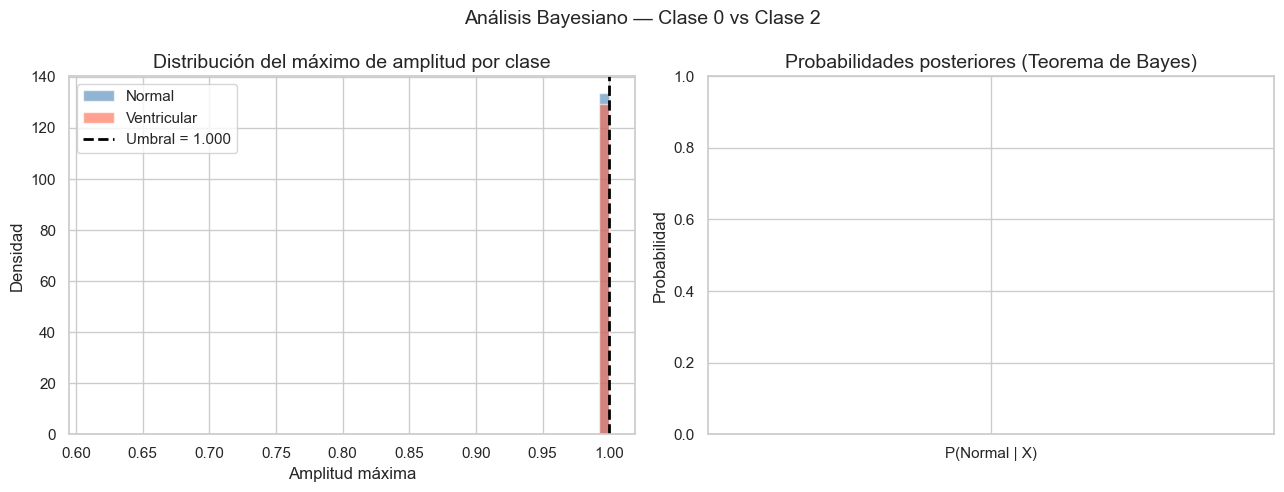

In [47]:
# === VISUALIZACIÓN DEL ANÁLISIS BAYESIANO ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución del máximo por clase con umbral
for clase, color, label in [(0, 'steelblue', 'Normal'), (2, 'tomato', 'Ventricular')]:
    vals = max_amplitud[y_bayes == clase]
    axes[0].hist(vals, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].axvline(umbral, color='black', linestyle='--', linewidth=2, label=f'Umbral = {umbral:.3f}')
axes[0].set_title('Distribución del máximo de amplitud por clase')
axes[0].set_xlabel('Amplitud máxima')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Barras de probabilidades posteriores
probs = [P_c0_dado_X, P_c2_dado_X]
etiquetas = ['P(Normal | X)', 'P(Ventricular | X)']
colores = ['steelblue', 'tomato']
bars = axes[1].bar(etiquetas, probs, color=colores, edgecolor='white', width=0.5)
for bar, prob in zip(bars, probs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{prob:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Probabilidades posteriores (Teorema de Bayes)')
axes[1].set_ylabel('Probabilidad')
axes[1].set_ylim(0, 1)

plt.suptitle('Análisis Bayesiano — Clase 0 vs Clase 2', fontsize=14)
plt.tight_layout()
plt.show()

---
## Apartado 5 — Conclusiones
**Puntuación: 15%**

### Resumen ejecutivo del proyecto

**Objetivo del sistema:** Clasificar latidos cardíacos como normales o anómalos para integrarlo en un sistema de alerta para smartwatches dirigido a mayores de 60 años.

#### Hallazgos del EDA
- El dataset presenta **desbalance severo**: la clase Normal representa ~83% de las muestras. Esta característica es clínicamente realista pero computacionalmente desafiante.
- Las señales normales exhiben morfología QRS bien definida y consistente. Las ventriculares presentan mayor anchura e irregularidad. Las de fusión combinan rasgos de ambas.
- El análisis descriptivo por latido revela que el **máximo de amplitud** y la **desviación típica** son buenos discriminadores entre clases.

#### Resultados del PCA
- Las dos primeras componentes explican un porcentaje limitado de la varianza total, lo que indica alta dimensionalidad intrínseca.
- El scatter muestra que la clase Normal forma un cluster reconocible, pero las clases anómalas se solapan considerablemente en 2D.

#### Comparativa de modelos
- Los tres modelos evaluados presentan trade-offs distintos entre precision y recall.
- En contexto clínico, **maximizar el Recall** de la clase Anómalo es prioritario: un falso negativo puede suponer un riesgo real para el paciente.
- [Completar con el modelo recomendado una vez ejecutado el notebook]

#### Análisis Bayesiano
- La evidencia de alta amplitud en la señal eleva la probabilidad de que el latido sea ventricular.
- El análisis muestra cómo ajustar el umbral modifica el balance entre sensibilidad y tasa de falsos positivos, un dilema clásico en diagnóstico médico.

#### Recomendación final
Para despliegue en un entorno de wearable real, se recomienda priorizar un modelo con Recall ≥ 0.85 para la clase anómala, aceptando cierto nivel de falsas alarmas como mecanismo de seguridad. El análisis bayesiano puede complementar el modelo para contextualizar alertas con probabilidades interpretables para el clínico.